In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import random

pd.options.display.max_rows = 5
CIRCUITY_FACTOR_GERMANY = 1.32
SHOW_FLIERS = False

# DISTANCE_RANGES = [(1, 5_000), (5_001, 10_000), (10_001, 15_000), (15_001, 20_000), (20_001, 25_000),
#                    (25_001, 30_000), (30_001, 35_000), (35_001, 40_000), (40_001, 45_000), (45_001, 50_000),
#                    (1, 50_000), (1, 20_000), (20_001, 50_000)]

# DISTANCE_RANGES = [(1, 5_000), (5_001, 10_000), (10_001, 15_000), (15_001, 20_000), (20_001, 25_000), (25_001, 30_000), (30_001, 50_000), (1, 50_000), (1, 20_000), (20_001, 50_000)]
DISTANCE_RANGES = [(1, 5_000), (5_001, 10_000), (10_001, 15_000), (15_001, 20_000), (20_001, 25_000), (25_001, 30_000), (30_001, 50_000)]

In [2]:
directory_to_evaluate = '../result_files/[diss results] 2026-03-17 10-44-39 (area_based)'


calculated_distances = pd.read_csv(f'{directory_to_evaluate}/distances.csv', sep=";")
crosses_water_lookup = pd.read_csv(f'{directory_to_evaluate}/crosses_water.csv', sep=";")
here_truth = pd.read_csv(f'../result_files/here_truth.csv', sep=";")

In [3]:
calculated_distances = pd.merge(
    calculated_distances,
    here_truth[['start_loc', 'dest_loc', 'distance_meters']].rename(columns={'distance_meters': 'here_distance'}),
    on=['start_loc', 'dest_loc'],
    # how='left'
)

only_distances = calculated_distances[['approach', 'distance_meters', 'here_distance', 'start_loc', 'dest_loc']].groupby(['approach', 'start_loc', 'dest_loc']).first().reset_index()
distance_truth = only_distances[only_distances['approach'] == 'OSRM'][['distance_meters', 'start_loc', 'dest_loc']]
distance_truth = distance_truth.merge(crosses_water_lookup, on=['start_loc', 'dest_loc'])
distance_airline = only_distances[only_distances['approach'] == 'HAVERSINE'][['distance_meters', 'start_loc', 'dest_loc']]

# merge only distances with truth distances on start_loc and dest_loc
only_distances = only_distances.merge(distance_truth, on=['start_loc', 'dest_loc'], suffixes=('', '_truth'))
only_distances = only_distances.merge(distance_airline, on=['start_loc', 'dest_loc'], suffixes=('', '_airline'))

In [4]:
SAMPLE_SIZE = 25_000

# Remove outliers (Here vs OSRM)
deviation_mask = (only_distances['distance_meters_truth'] - only_distances['here_distance']).abs() / only_distances['distance_meters_truth'] <= 0.10
only_distances = only_distances.loc[deviation_mask].copy()

only_distances['pair'] = list(zip(only_distances['start_loc'], only_distances['dest_loc']))
pairs_per_approach = only_distances.groupby('approach')['pair'].apply(set)
common_pairs = set.intersection(*pairs_per_approach)

random.seed(123) # ensure reproducibility!
sampled_pairs = random.sample(list(common_pairs), SAMPLE_SIZE)
only_distances = only_distances[only_distances['pair'].isin(sampled_pairs)].copy()

only_distances[only_distances['approach'] == 'BRIDGE_SPLIT_NO_REC'].shape

(25102, 16)

In [5]:
only_distances.loc[only_distances['approach'] == 'HAVERSINE','distance_meters'] = only_distances[only_distances['approach'] == 'HAVERSINE']['distance_meters'] * CIRCUITY_FACTOR_GERMANY
only_distances.loc[only_distances['approach'] == 'BRIDGE_SPLIT_NO_REC','distance_meters'] = only_distances[only_distances['approach'] == 'BRIDGE_SPLIT_NO_REC']['distance_meters'] * CIRCUITY_FACTOR_GERMANY
only_distances.loc[only_distances['approach'] == 'HYBRID_BRIDGE_SPLIT','distance_meters'] = only_distances[only_distances['approach'] == 'HYBRID_BRIDGE_SPLIT']['distance_meters'] * CIRCUITY_FACTOR_GERMANY
only_distances['percentage_error'] = ((only_distances['distance_meters'] - only_distances['distance_meters_truth']).abs() / only_distances['distance_meters_truth']) * 100

# True Distance Distribution of Random Paths

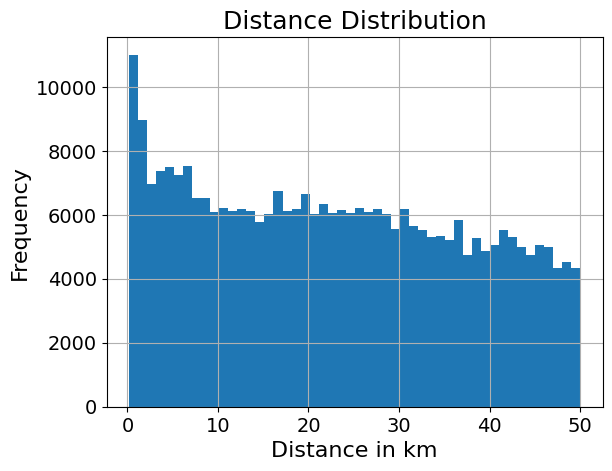

In [6]:
# distance distribution for using multiple districts
# only_distances['distance_km'] = only_distances['distance_meters'] / 1000
# only_distances[only_distances.approach == "HAVERSINE"]['distance_km'].hist(bins=55)

only_distances['distance_km_truth'] = only_distances['distance_meters_truth'] / 1000
only_distances['distance_km_truth'].hist(bins=50)

# add title and labels, increase font size
plt.title('Distance Distribution', fontsize=18)
plt.xlabel('Distance in km', fontsize=16)
plt.ylabel('Frequency', fontsize=16)

# increase font size of ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

## Analyze presence of crossed water areas

In [7]:
results = {}

_tmp = only_distances[only_distances['approach'] == 'OSRM']

for distance_range in DISTANCE_RANGES:
        results[f'{distance_range[0]}-{distance_range[1]}'] = {}
        _filtered = _tmp[(_tmp['distance_meters'] >= distance_range[0]) &
                                      (_tmp['distance_meters'] < distance_range[1])]

        results[f'{distance_range[0]}-{distance_range[1]}']["Crosses Waterbody"] = _filtered['crosses_water'].mean() * 100
        results[f'{distance_range[0]}-{distance_range[1]}']["Crosses River"] = _filtered['crosses_river'].mean() * 100
        results[f'{distance_range[0]}-{distance_range[1]}']["Crosses Water"] = (_filtered[(_filtered['crosses_river'] == True) | (_filtered['crosses_water'] == True)]).count().iloc[0] / _filtered.shape[0] * 100

df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Distance (km)'})
df['Distance (km)'] = df['Distance (km)'].apply(lambda x: f"{(int(x.split('-')[0])-1)/1000:.0f}-{(int(x.split('-')[1]))/1000:.0f}")

# os.makedirs("Figures and Tables", exist_ok=True)
# df.style.hide(axis="index").highlight_min(
#     axis=0, props="textbf:--rwrap;").format(
#     decimal='.', thousands=',', precision=2, na_rep="-").to_latex(
#    f"Figures and Tables/water_area_crossed_per_distance.tex",
#     hrules=True)

df

,Distance (km),Crosses Waterbody,Crosses River,Crosses Water
0,0-5,20.976331,20.798817,21.568047
1,5-10,35.226078,34.630214,35.821942
...,...,...,...,...
5,25-30,52.130625,51.493429,52.369574
6,30-50,66.732489,66.418864,67.197119


# Airline Distance Distribution of Random Paths

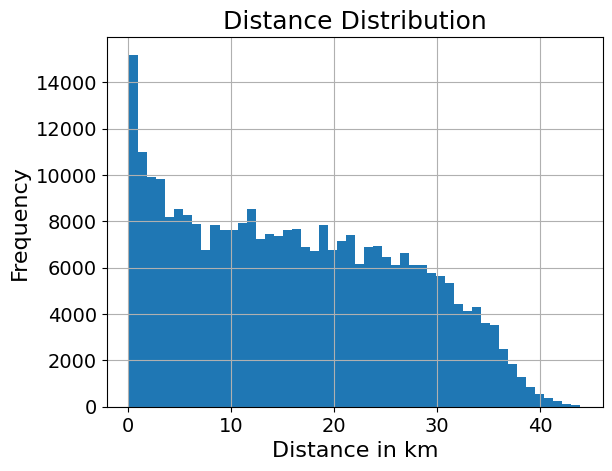

In [8]:
# distance distribution for using multiple districts
# only_distances['distance_km'] = only_distances['distance_meters'] / 1000
# only_distances[only_distances.approach == "HAVERSINE"]['distance_km'].hist(bins=55)

only_distances['distance_km_airline'] = only_distances['distance_meters_airline'] / 1000
only_distances['distance_km_airline'].hist(bins=50)

# add title and labels, increase font size
plt.title('Distance Distribution', fontsize=18)
plt.xlabel('Distance in km', fontsize=16)
plt.ylabel('Frequency', fontsize=16)

# increase font size of ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()

In [9]:
results = {}

_tmp = only_distances[only_distances['approach'] == 'HAVERSINE']

for distance_range in DISTANCE_RANGES:
        results[f'{distance_range[0]}-{distance_range[1]}'] = {}
        _filtered = _tmp[(_tmp['distance_meters'] >= distance_range[0]) &
                                      (_tmp['distance_meters'] < distance_range[1])]

        results[f'{distance_range[0]}-{distance_range[1]}']["Crosses Waterbody"] = _filtered['crosses_water'].mean() * 100
        results[f'{distance_range[0]}-{distance_range[1]}']["Crosses River"] = _filtered['crosses_river'].mean() * 100
        results[f'{distance_range[0]}-{distance_range[1]}']["Crosses Water"] = (_filtered[(_filtered['crosses_river'] == True) | (_filtered['crosses_water'] == True)]).count().iloc[0] / _filtered.shape[0] * 100

df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Distance (km)'})
df['Distance (km)'] = df['Distance (km)'].apply(lambda x: f"{(int(x.split('-')[0])-1)/1000:.0f}-{(int(x.split('-')[1]))/1000:.0f}")

# os.makedirs("Figures and Tables", exist_ok=True)
# df.style.hide(axis="index").highlight_min(
#     axis=0, props="textbf:--rwrap;").format(
#     decimal='.', thousands=',', precision=2, na_rep="-").to_latex(
#    f"Figures and Tables/water_area_crossed_per_distance.tex",
#     hrules=True)

df

,Distance (km),Crosses Waterbody,Crosses River,Crosses Water
0,0-5,25.126008,24.873992,25.655242
1,5-10,33.367947,33.021807,33.991000
...,...,...,...,...
5,25-30,56.301857,55.432635,56.657448
6,30-50,67.494171,67.233576,67.974215


# Haversine Weakness Identification

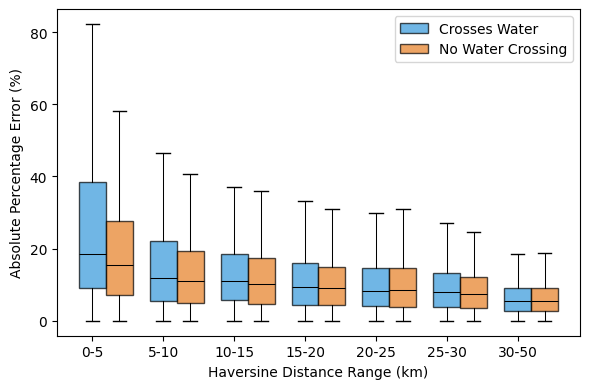

In [15]:
percentage_error_distance_ranges_all = []
percentage_error_distance_ranges_crosses = []
percentage_error_distance_ranges_no_water = []
labels = []

for distance_range in DISTANCE_RANGES:
    _distance_filtered = only_distances[(only_distances.approach == 'HAVERSINE') & (only_distances['distance_meters_airline'] >= distance_range[0]) & (only_distances['distance_meters_airline'] < distance_range[1])]
    # _distance_filtered = only_distances[(only_distances.approach == 'HAVERSINE') & (only_distances['distance_meters_truth'] >= distance_range[0]) & (only_distances['distance_meters_truth'] < distance_range[1])]
    # _distance_filtered = only_distances[(only_distances.approach == 'HAVERSINE') & (only_distances['distance_meters'] >= distance_range[0]) & (only_distances['distance_meters'] < distance_range[1])]

    _errors = _distance_filtered['percentage_error'].tolist()
    # _errors_crosses = _distance_filtered[(_distance_filtered['crosses_water'] == True) | (_distance_filtered['crosses_river'] == True)]['percentage_error'].tolist()
    _errors_crosses = _distance_filtered[(_distance_filtered['crosses_river'] == True)]['percentage_error'].tolist()

    # _errors_no_water = _distance_filtered[(_distance_filtered['crosses_water'] == False) & (_distance_filtered['crosses_river'] == False)]['percentage_error'].tolist()
    _errors_no_water = _distance_filtered[(_distance_filtered['crosses_river'] == False)]['percentage_error'].tolist()

    _label = f'{distance_range[0]/1000:.0f}-{distance_range[1]/1000:.0f}'

    labels.append(_label)
    percentage_error_distance_ranges_all.append(_errors)
    percentage_error_distance_ranges_crosses.append(_errors_crosses)
    percentage_error_distance_ranges_no_water.append(_errors_no_water)


fig, ax = plt.subplots(figsize=(12, 6))

# 1. Setup positions and widths
n_groups = len(labels)
index = np.arange(1, n_groups + 1)
width = 0.38  # Width of each box

# 2. Plot each category with an offset
bp2 = ax.boxplot(percentage_error_distance_ranges_crosses,
                 positions=index, widths=width,
                 patch_artist=True, showfliers=SHOW_FLIERS)

bp3 = ax.boxplot(percentage_error_distance_ranges_no_water,
                 positions=index + width, widths=width,
                 patch_artist=True, showfliers=SHOW_FLIERS)


# Define styles
colors = ['#3498db', '#e67e22']  # Blue, Orange, Green
median_props = dict(color='black', linewidth=2) # High contrast median
bplots = [bp2, bp3]
labels_legend = ['Crosses Water', 'No Water Crossing']

for i, bplot in enumerate(bplots):
    # Style the box fill
    for patch in bplot['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7) # Slight transparency helps visibility

    # Style the median lines specifically
    for median in bplot['medians']:
        median.set_color('black') # Or 'white' if using very dark boxes
        median.set_linewidth(.75)

    # Optional: Style the whiskers/caps to match
    for whisker in bplot['whiskers']:
        whisker.set_linewidth(.75)

# 4. Clean up the axes
ax.set_xticks(index)
ax.set_xticklabels(labels)
ax.set_ylabel('Absolute Percentage Error (%)')
ax.set_xlabel('Haversine Distance Range (km)')
# ax.set_title('Error Comparison by Water Crossing')

# 5. Add a legend
ax.legend([bp2["boxes"][0], bp3["boxes"][0]], labels_legend, loc='upper right')

fig = plt.gcf() # "Get Current Figure"
fig.set_size_inches(6, 4)

plt.tight_layout()
os.makedirs("Figures and Tables/Motivation", exist_ok=True)
plt.savefig('Figures and Tables/Motivation/distance_error_analysis_motivation.pdf',
            format='pdf',
            bbox_inches='tight',
            dpi=300)

## For Diss

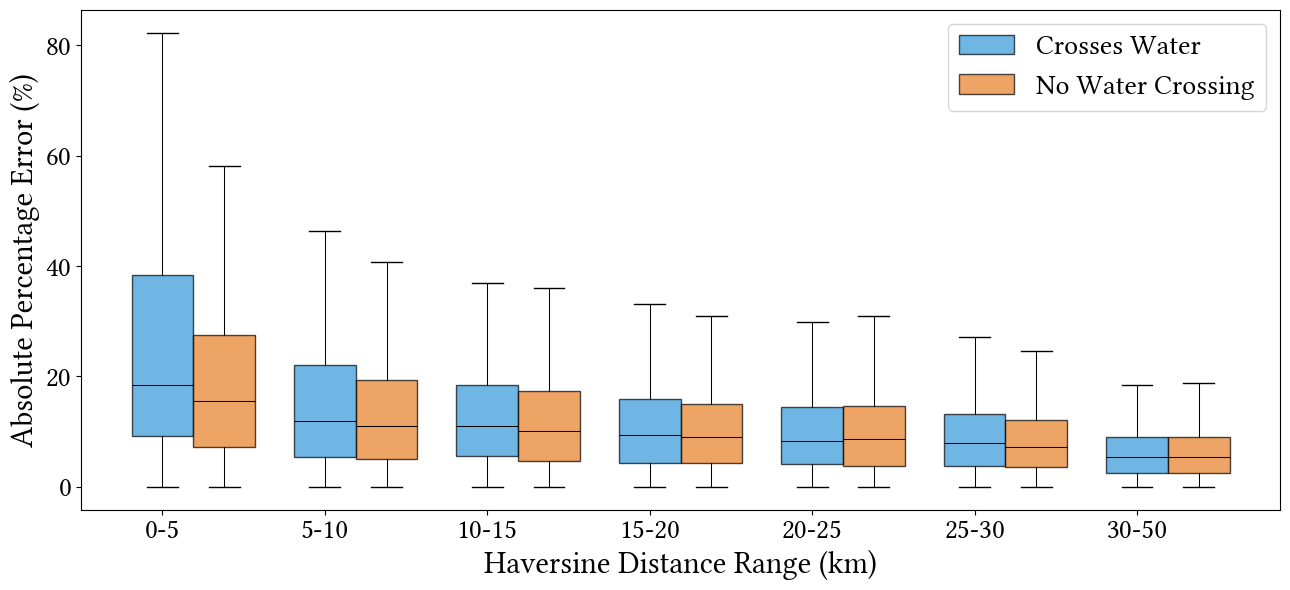

In [23]:
font_tmp = mpl.rcParams['font.family']
mpl.rcParams['font.family'] = 'Linux Libertine'

fig, ax = plt.subplots(figsize=(13, 6))

# 1. Setup positions and widths
n_groups = len(labels)
index = np.arange(1, n_groups + 1)
width = 0.38  # Width of each box

# 2. Plot each category with an offset
bp2 = ax.boxplot(percentage_error_distance_ranges_crosses,
                 positions=index, widths=width,
                 patch_artist=True, showfliers=SHOW_FLIERS)

bp3 = ax.boxplot(percentage_error_distance_ranges_no_water,
                 positions=index + width, widths=width,
                 patch_artist=True, showfliers=SHOW_FLIERS)


# Define styles
colors = ['#3498db', '#e67e22']  # Blue, Orange, Green
median_props = dict(color='black', linewidth=2) # High contrast median
bplots = [bp2, bp3]
labels_legend = ['Crosses Water', 'No Water Crossing']

for i, bplot in enumerate(bplots):
    # Style the box fill
    for patch in bplot['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7) # Slight transparency helps visibility

    # Style the median lines specifically
    for median in bplot['medians']:
        median.set_color('black') # Or 'white' if using very dark boxes
        median.set_linewidth(.75)

    # Optional: Style the whiskers/caps to match
    for whisker in bplot['whiskers']:
        whisker.set_linewidth(.75)

ax.set_xticks(index, labels=labels, fontsize=20)
ax.tick_params(axis='y', labelsize=20)
ax.set_ylabel('Absolute Percentage Error (%)', fontsize=22)
ax.set_xlabel('Haversine Distance Range (km)', fontsize=22)
# ax.set_title('Error Comparison by Water Crossing')

# 5. Add a legend
ax.legend([bp2["boxes"][0], bp3["boxes"][0]], labels_legend, loc='upper right', fontsize=20)

# fig = plt.gcf() # "Get Current Figure"
# fig.set_size_inches(13, 6)

plt.tight_layout()
os.makedirs("Figures and Tables/Motivation", exist_ok=True)
plt.savefig('Figures and Tables/Motivation/4 - distance_error_analysis_motivation.pdf',
            format='pdf',
            bbox_inches='tight',
            dpi=300)

mpl.rcParams['font.family'] = font_tmp

# Bridge Route Split Improvements

In [11]:
only_distances.approach.unique()

array(['BRIDGE_SPLIT_NO_REC', 'BRIDGE_SPLIT_REC', 'HAVERSINE',
       'HYBRID_BRIDGE_SPLIT_HAVERSINE', 'HYBRID_BRIDGE_SPLIT_OHG',
       'HYBRID_WATER_GRAPH_HAVERSINE', 'HYBRID_WATER_GRAPH_OHG', 'OSRM',
       'OVERHEAD_GRAPH_1024', 'OVERHEAD_GRAPH_256', 'OVERHEAD_GRAPH_512',
       'WATER_GRAPH_CIRCUITY'], dtype=object)

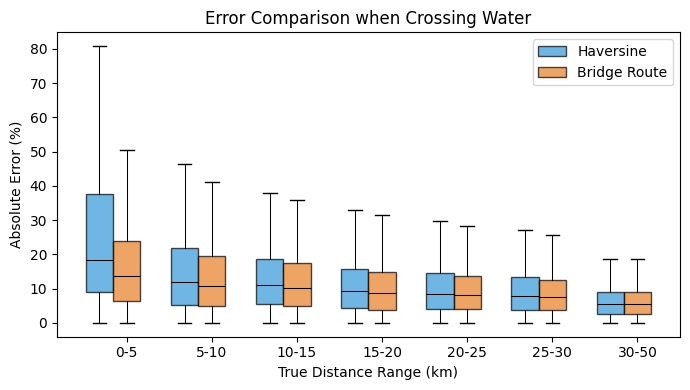

In [12]:
percentage_error_distance_ranges_crosses_haversine = []
percentage_error_distance_ranges_crosses_bridge = []
labels = []

for distance_range in DISTANCE_RANGES:
    # _distance_filtered = _tmp[(_tmp['distance_meters_truth'] >= distance_range[0]) & (_tmp['distance_meters_truth'] < distance_range[1])]
    # _distance_filtered = only_distances[(only_distances['distance_meters_truth'] >= distance_range[0]) & (only_distances['distance_meters_truth'] < distance_range[1])]
    _distance_filtered = only_distances[(only_distances['distance_meters_airline'] >= distance_range[0]) & (only_distances['distance_meters_airline'] < distance_range[1])]
    _distance_filtered = _distance_filtered.dropna()

    _errors_haversine = _distance_filtered[(_distance_filtered.approach == 'HAVERSINE') & ((_distance_filtered['crosses_water'] == True) | (_distance_filtered['crosses_river'] == True))]['percentage_error'].tolist()
    # _errors_bridge = _distance_filtered[(_distance_filtered.approach == 'BRIDGE_SPLIT_NO_REC') & ((_distance_filtered['crosses_water'] == True) | (_distance_filtered['crosses_river'] == True))]['percentage_error'].tolist()
    _errors_bridge = _distance_filtered[(_distance_filtered.approach == 'BRIDGE_SPLIT_NO_REC') & ((_distance_filtered['crosses_water'] == True) | (_distance_filtered['crosses_river'] == True))]['percentage_error'].tolist()

    _label = f'{distance_range[0]/1000:.0f}-{distance_range[1]/1000:.0f}'

    labels.append(_label)
    percentage_error_distance_ranges_crosses_haversine.append(_errors_haversine)
    percentage_error_distance_ranges_crosses_bridge.append(_errors_bridge)


fig, ax = plt.subplots(figsize=(12, 6))

# 1. Setup positions and widths
n_groups = len(labels)
index = np.arange(1, n_groups + 1)
width = 0.32  # Width of each box

# 2. Plot each category with an offset
bp1 = ax.boxplot(percentage_error_distance_ranges_crosses_haversine,
                 positions=index - width, widths=width,
                 patch_artist=True, showfliers=SHOW_FLIERS)

bp2 = ax.boxplot(percentage_error_distance_ranges_crosses_bridge,
                 positions=index, widths=width,
                 patch_artist=True, showfliers=SHOW_FLIERS)


# Define styles
colors = ['#3498db', '#e67e22', '#2ecc71']  # Blue, Orange, Green
median_props = dict(color='black', linewidth=2) # High contrast median
bplots = [bp1, bp2]
labels_legend = ['Haversine', 'Bridge Route']

for i, bplot in enumerate(bplots):
    # Style the box fill
    for patch in bplot['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7) # Slight transparency helps visibility

    # Style the median lines specifically
    for median in bplot['medians']:
        median.set_color('black') # Or 'white' if using very dark boxes
        median.set_linewidth(.75)

    # Optional: Style the whiskers/caps to match
    for whisker in bplot['whiskers']:
        whisker.set_linewidth(.75)

# 4. Clean up the axes
ax.set_xticks(index)
ax.set_xticklabels(labels)
ax.set_ylabel('Absolute Error (%)')
ax.set_xlabel('True Distance Range (km)')
ax.set_title('Error Comparison when Crossing Water')

# 5. Add a legend
ax.legend([bp1["boxes"][0], bp2["boxes"][0], bp3["boxes"][0]],
          labels_legend, loc='upper right')

fig = plt.gcf() # "Get Current Figure"
fig.set_size_inches(7, 4)

plt.tight_layout()
os.makedirs("Figures and Tables/Motivation", exist_ok=True)
plt.savefig('Figures and Tables/Motivation/haversine_BridgeSplit.pdf',
            format='pdf',
            bbox_inches='tight',
            dpi=300)